# Load and Explore Dataset

PPT to images

In [6]:
from pptx import Presentation
from PIL import Image
import os

def ppt_to_images(ppt_file, output_folder):
    # Load presentation
    prs = Presentation(ppt_file)

    # Create output directory if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Loop through each slide
    for i, slide in enumerate(prs.slides):
        # Create a blank image for each slide (you can set size)
        img = Image.new('RGB', (1920, 1080), color=(255, 255, 255))

        # Placeholder for where content of the slide should go
        # (optional: rendering slide content here is tricky and would require more work)

        # Save each slide as an image
        img_path = os.path.join(output_folder, f'slide_{i + 1}.png')
        img.save(img_path)

    print(f"All slides saved as images in {output_folder}")

# Example usage
ppt_file = 'your_presentation.pptx'  # Replace with your ppt file path


In [7]:
#################   Load the dataset  ###############################

In [8]:
import pandas as pd

# Specify the path to your CSV file
file_path = "../data/image_pairs_labels.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


# Display the first few rows of the DataFrame
print(df.head())

# Assuming the DataFrame `df` has the same structure
image_pairs = list(zip(df['img1_path'], df['img2_path']))
style_labels = df['style_label'].tolist()
font_labels = df['font_label'].tolist()

# Now `image_pairs`, `style_labels`, and `font_labels` are reconstructed

df['original_index'] = df.index

                                        img1_path  \
0  C:\Users\maria\Downloads\dataset\img1_3163.png   
1  C:\Users\maria\Downloads\dataset\img1_1868.png   
2   C:\Users\maria\Downloads\dataset\img1_102.png   
3   C:\Users\maria\Downloads\dataset\img1_873.png   
4  C:\Users\maria\Downloads\dataset\img1_2750.png   

                                        img2_path  style_label  font_label  
0  C:\Users\maria\Downloads\dataset\img2_3163.png            0           1  
1  C:\Users\maria\Downloads\dataset\img2_1868.png            1           1  
2   C:\Users\maria\Downloads\dataset\img2_102.png            0           0  
3   C:\Users\maria\Downloads\dataset\img2_873.png            0           1  
4  C:\Users\maria\Downloads\dataset\img2_2750.png            0           0  


In [9]:
df.head()

,img1_path,img2_path,style_label,font_label,original_index
0,C:\Users\maria\Downloads\dataset\img1_3163.png,C:\Users\maria\Downloads\dataset\img2_3163.png,0,1,0
1,C:\Users\maria\Downloads\dataset\img1_1868.png,C:\Users\maria\Downloads\dataset\img2_1868.png,1,1,1
2,C:\Users\maria\Downloads\dataset\img1_102.png,C:\Users\maria\Downloads\dataset\img2_102.png,0,0,2
3,C:\Users\maria\Downloads\dataset\img1_873.png,C:\Users\maria\Downloads\dataset\img2_873.png,0,1,3
4,C:\Users\maria\Downloads\dataset\img1_2750.png,C:\Users\maria\Downloads\dataset\img2_2750.png,0,0,4


In [10]:
import numpy as np
from PIL import Image # Import the PIL library


# Example training data (this is just a placeholder)
# image_pairs = [(img1, img2), (img3, img4), ...]
# style_labels = [0, 1, ...]  # Binary labels for style coherence
# font_labels = [0, 1, ...]   # Binary labels for font similarity

# Convert to numpy arrays
image_pairs = np.array(image_pairs)
style_labels = np.array(style_labels)
font_labels = np.array(font_labels)

# Function to load and preprocess an image
def load_and_preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.resize((256, 256))  # Resize to match input shape
    img = np.array(img) / 255.0  # Normalize pixel values
    return img

# Load and preprocess the images
images_1 = np.array([load_and_preprocess_image(path) for path in image_pairs[:, 0]])
images_2 = np.array([load_and_preprocess_image(path) for path in image_pairs[:, 1]])


In [11]:
len(font_labels)

6000

# Model *training* multy lable output

In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

def create_cnn_branch(vgg_base, branch_name, input_tensor):
    # Use the shared VGG16 base model to process the input
    x = vgg_base(input_tensor)
    
    # Fewer Conv2D layers and reduced filter sizes
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same', name=branch_name + '_conv1')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool1')(x)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name=branch_name + '_conv2')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool2')(x)

    # Replace GlobalAveragePooling with Flatten
    x = layers.Flatten(name=branch_name + '_flatten')(x)

    return x

def create_dual_branch_model(input_shape):
     # Load the pre-trained VGG16 model (without the top classification layers)
    vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the layers of VGG16
    for layer in vgg_base.layers:
        layer.trainable = False

    # Define two separate inputs
    input_1 = layers.Input(shape=input_shape, name='input_1')
    input_2 = layers.Input(shape=input_shape, name='input_2')

    # Create two branches using the shared VGG16 base model
    branch_output_1 = create_cnn_branch(vgg_base, branch_name="branch1", input_tensor=input_1)
    branch_output_2 = create_cnn_branch(vgg_base, branch_name="branch2", input_tensor=input_2)

    # Combine the outputs from both branches
    combined = layers.Concatenate(name='concatenate')([branch_output_1, branch_output_2])

    # Smaller final dense layers for classification
    x = layers.Dense(128, activation='relu', name='fc_combined')(combined)
    
    # Output for style coherence
    style_output = layers.Dense(1, activation='sigmoid', name='style_output')(x)

    # Output for font similarity
    font_output = layers.Dense(1, activation='sigmoid', name='font_output')(x)

    # Create the final model
    model = Model(inputs=[input_1, input_2], outputs=[style_output, font_output])

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss={'style_output': 'binary_crossentropy', 'font_output': 'binary_crossentropy'},
                  metrics={'style_output': 'accuracy', 'font_output': 'accuracy'})

    return model

In [ ]:
import numpy as np
from PIL import Image # Import the PIL library
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping

# Input shape is 220x220 with 3 channels (RGB)
input_shape = (256, 256, 3)

# Create the dual-input model
dual_direction_model = create_dual_branch_model(input_shape)

# Summary of the model
dual_direction_model.summary()

# Example training data (this is just a placeholder)
# image_pairs = [(img1, img2), (img3, img4), ...]
# style_labels = [0, 1, ...]  # Binary labels for style coherence
# font_labels = [0, 1, ...]   # Binary labels for font similarity

# Convert to numpy arrays
image_pairs = np.array(image_pairs)
style_labels = np.array(style_labels)
font_labels = np.array(font_labels)

# Function to load and preprocess an image
def load_and_preprocess_image(image_path):
    img = Image.open(image_path)
    img = img.resize((256, 256))  # Resize to match input shape
    img = np.array(img) / 255.0  # Normalize pixel values
    return img

# Load and preprocess the images
images_1 = np.array([load_and_preprocess_image(path) for path in image_pairs[:, 0]])
images_2 = np.array([load_and_preprocess_image(path) for path in image_pairs[:, 1]])

from sklearn.model_selection import train_test_split

# Split the data into training (60%) and a temporary set (40%)
X_train_1, X_temp_1, y_style_train, y_style_temp = train_test_split(images_1, style_labels, test_size=0.4, random_state=42)
X_train_2, X_temp_2, y_font_train, y_font_temp = train_test_split(images_2, font_labels, test_size=0.4, random_state=42)

# Split the temporary set into validation (20%) and test sets (20%)
X_val_1, X_test_1, y_style_val, y_style_test = train_test_split(X_temp_1, y_style_temp, test_size=0.5, random_state=42)
X_val_2, X_test_2, y_font_val, y_font_test = train_test_split(X_temp_2, y_font_temp, test_size=0.5, random_state=42)


# Create the model
input_shape = (256, 256, 3)  # Assuming 224x224 images with 3 channels (RGB)
model = create_dual_branch_model(input_shape)

# Define callbacks for learning rate scheduling and early stopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with callbacks
history = model.fit(
    [X_train_1, X_train_2],  # Inputs for both branches
    {'style_output': y_style_train, 'font_output': y_font_train},  # Targets for both outputs
    validation_data=(
        [X_test_1, X_test_2],
        {'style_output': y_style_test, 'font_output': y_font_test}
    ),
    epochs=100,
    batch_size=16,
    callbacks=[reduce_lr, early_stopping]
)


# Evaluate on validation set
val_results = model.evaluate(
    [X_val_1, X_val_2],  # Validation inputs for both images
    {'style_output': y_style_val, 'font_output': y_font_val}  # Validation labels
)

print(f"Validation Loss and Metrics: {val_results}")


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 vgg16 (Functional)             (None, 7, 7, 512)    14714688    ['input_1[0][0]',                
                                                                  'input_2[0][0]']            

# MODEL FOCUSED ON STYLE ONLY training

In [ ]:
#pip install numpy==1.19.5

In [5]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dropout, GlobalAveragePooling2D, Dense, Conv2D, MaxPooling2D, Input, Concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import numpy as np
import time

# Function to create the CNN branch for each input
def create_cnn_branch(input_shape, branch_name, input_tensor):
    # First convolutional block
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name=branch_name + '_conv1')(input_tensor)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool1')(x)

    # Second convolutional block
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name=branch_name + '_conv2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool2')(x)

    # Third convolutional block
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name=branch_name + '_conv3')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool3')(x)

    # Fourth convolutional block (Newly added)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name=branch_name + '_conv4')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool4')(x)

    # Global average pooling
    x = GlobalAveragePooling2D(name=branch_name + '_global_pool')(x)

    # Fully connected layer with L2 regularization and dropout
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01), name=branch_name + '_fc')(x)
    x = Dropout(0.5)(x)

    return x
    
    def create_dual_branch_model(input_shape):
        # Define two separate inputs
        input_1 = Input(shape=input_shape, name='input_1')
        input_2 = Input(shape=input_shape, name='input_2')
    
        # Create two branches with custom CNN layers
        branch_output_1 = create_cnn_branch(input_shape, branch_name="branch1", input_tensor=input_1)
        branch_output_2 = create_cnn_branch(input_shape, branch_name="branch2", input_tensor=input_2)
    
        # Combine the outputs from both branches
        combined = Concatenate(name='concatenate')([branch_output_1, branch_output_2])
    
        # Add fully connected layers after concatenation with optimized architecture
        x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='fc_combined_1')(combined)
        x = BatchNormalization()(x)
        x = Dropout(0.5)(x)  
    
        x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='fc_combined_2')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.4)(x)  
    
        # Output layer for style coherence (binary classification)
        style_output = Dense(1, activation='sigmoid', name='style_output')(x)
    
        # Create the final model
        model = Model(inputs=[input_1, input_2], outputs=style_output)
    
        # Compile the model with an advanced optimizer and dynamic learning rate
        model.compile(optimizer=Adam(learning_rate=3e-4),  # Increased learning rate slightly for faster convergence
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
    
        return model


# # Function to create the dual branch model
# def create_dual_branch_model(input_shape):
#     # Define two separate inputs
#     input_1 = Input(shape=input_shape, name='input_1')
#     input_2 = Input(shape=input_shape, name='input_2')

#     # Create two branches with custom CNN layers
#     branch_output_1 = create_cnn_branch(input_shape, branch_name="branch1", input_tensor=input_1)
#     branch_output_2 = create_cnn_branch(input_shape, branch_name="branch2", input_tensor=input_2)

#     # Combine the outputs from both branches
#     combined = Concatenate(name='concatenate')([branch_output_1, branch_output_2])

#     # Add fully connected layers after concatenation (increased complexity)
#     x = Dense(1028, activation='relu', kernel_regularizer=regularizers.l2(0.01),  name='fc_combined_1')(combined)
#     x = BatchNormalization()(x)
#     x = Dropout(0.5)(x)

#     x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='fc_combined_2')(x)
#     x = BatchNormalization()(x)
#     x = Dropout(0.5)(x)
       
#     # Output layer for style coherence (binary classification)
#     style_output = Dense(1, activation='sigmoid', name='style_output')(x)

#     # Create the final model
#     model = Model(inputs=[input_1, input_2], outputs=style_output)

#     # Compile the model with a slightly lower learning rate
#     model.compile(optimizer=Adam(learning_rate=1e-4),  # Increased learning rate slightly
#                   loss='binary_crossentropy',
#                   metrics=['accuracy'])

#     return model

# Create the model
input_shape = (256, 256, 3)  # Assuming 224x224 images with 3 channels (RGB)
model = create_dual_branch_model(input_shape)
    
# # Assuming you have images_1, images_2, and y_style as input data
# # Split the data
# X_train_1, X_temp_1, X_train_2, X_temp_2, y_style_train, y_style_temp = train_test_split(
#     images_1, images_2, style_labels, test_size=0.6, random_state=42)  # 60% train, 40% (validation + test)

# # Split the temp data into validation and test sets
# X_val_1, X_test_1, X_val_2, X_test_2, y_style_val, y_style_test = train_test_split(
#     X_temp_1, X_temp_2, y_style_temp, test_size=0.5, random_state=42)  # 20% val, 20% test

# # Create the model
# input_shape = (224, 224, 3)  # Assuming 224x224 images with 3 channels (RGB)
# model = create_dual_branch_model(input_shape)

# Define callbacks for learning rate scheduling and early stopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # Train the model with the callbacks
# history = model.fit([X_train_1, X_train_2], y_style_train,
#                     validation_data=([X_test_1, X_test_2], y_style_test),
#                     epochs=100,
#                     batch_size=16,
#                     callbacks=[reduce_lr, early_stopping])

# Assuming images_1, images_2, style_labels are numpy arrays or lists of images and labels
X_train_1, X_test_1, X_train_2, X_test_2, y_train, y_test,  train_indices, test_indices = train_test_split(
    images_1, images_2, style_labels, df['original_index'].values, test_size=0.6, random_state=42, stratify=style_labels 
)

from sklearn.model_selection import KFold
import numpy as np

# Initialize KFold
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# Example of tracking training time
start_time = time.time()
# Loop over each fold
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_1, y_train)):
    print(f"Training on fold {fold + 1}")
    
    # Split the data into training and validation sets for this fold
    X_train_fold_1, X_val_fold_1 = np.array(X_train_1)[train_idx], np.array(X_train_1)[val_idx]
    X_train_fold_2, X_val_fold_2 = np.array(X_train_2)[train_idx], np.array(X_train_2)[val_idx]
    y_train_fold, y_val_fold = np.array(y_train)[train_idx], np.array(y_train)[val_idx]
    
    # Train the model on this fold
    history = model.fit(
        [X_train_fold_1, X_train_fold_2],  # Inputs for both branches
        {'style_output': y_train_fold},  # Targets
        validation_data=(
            [X_val_fold_1, X_val_fold_2],
            {'style_output': y_val_fold}
        ),
        epochs=100,
        batch_size=32,
        callbacks=[reduce_lr, early_stopping]
    )
    
    # Optionally collect history for each fold
    print(f"Fold {fold + 1} completed.")
    
end_time = time.time()

# Calculate and print the training time
training_time = end_time - start_time
print("Training Time: ", training_time, "seconds")
    
# Evaluate the model on the hold-out test set
test_loss, test_accuracy = model.evaluate(
    [X_test_1, X_test_2],  # Inputs for both branches
    {'style_output': y_test}  # Test labels
)

print(f"Test accuracy: {test_accuracy}")




NameError: name 'create_dual_branch_model' is not defined

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dropout, GlobalAveragePooling2D, Dense, Conv2D, MaxPooling2D, Input, Concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import numpy as np
import time

# Function to create the CNN branch for each input
def create_cnn_branch(input_shape, branch_name, input_tensor):
    # First convolutional block
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name=branch_name + '_conv1')(input_tensor)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool1')(x)

    # Second convolutional block
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name=branch_name + '_conv2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool2')(x)

    # Third convolutional block
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name=branch_name + '_conv3')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool3')(x)

    # Fourth convolutional block (Newly added)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name=branch_name + '_conv4')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool4')(x)

    # Global average pooling
    x = GlobalAveragePooling2D(name=branch_name + '_global_pool')(x)

    # Fully connected layer with L2 regularization and dropout
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01), name=branch_name + '_fc')(x)
    x = Dropout(0.5)(x)

    return x
    
    def create_dual_branch_model(input_shape):
        # Define two separate inputs
        input_1 = Input(shape=input_shape, name='input_1')
        input_2 = Input(shape=input_shape, name='input_2')
    
        # Create two branches with custom CNN layers
        branch_output_1 = create_cnn_branch(input_shape, branch_name="branch1", input_tensor=input_1)
        branch_output_2 = create_cnn_branch(input_shape, branch_name="branch2", input_tensor=input_2)
    
        # Combine the outputs from both branches
        combined = Concatenate(name='concatenate')([branch_output_1, branch_output_2])
    
        # Add fully connected layers after concatenation with optimized architecture
        x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='fc_combined_1')(combined)
        x = BatchNormalization()(x)
        x = Dropout(0.5)(x)  
    
        x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='fc_combined_2')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.4)(x)  

        x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='fc_combined_3')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.55)(x)

    
        # Output layer for style coherence (binary classification)
        style_output = Dense(1, activation='sigmoid', name='style_output')(x)
    
        # Create the final model
        model = Model(inputs=[input_1, input_2], outputs=style_output)
    
        # Compile the model with an advanced optimizer and dynamic learning rate
        model.compile(optimizer=Adam(learning_rate=3e-4),  # Increased learning rate slightly for faster convergence
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
    
        return model


# Create the model
input_shape = (256, 256, 3)  # Assuming 224x224 images with 3 channels (RGB)
model = create_dual_branch_model(input_shape)

# Define callbacks for learning rate scheduling and early stopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Assuming images_1, images_2, style_labels are numpy arrays or lists of images and labels
X_train_1, X_test_1, X_train_2, X_test_2, y_train, y_test,  train_indices, test_indices = train_test_split(
    images_1, images_2, style_labels, df['original_index'].values, test_size=0.2, random_state=42, stratify=style_labels 
)

from sklearn.model_selection import KFold
import numpy as np

# Initialize KFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Example of tracking training time
start_time = time.time()
# Loop over each fold
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_1, y_train)):
    print(f"Training on fold {fold + 1}")
    
    # Split the data into training and validation sets for this fold
    X_train_fold_1, X_val_fold_1 = np.array(X_train_1)[train_idx], np.array(X_train_1)[val_idx]
    X_train_fold_2, X_val_fold_2 = np.array(X_train_2)[train_idx], np.array(X_train_2)[val_idx]
    y_train_fold, y_val_fold = np.array(y_train)[train_idx], np.array(y_train)[val_idx]
    
    # Train the model on this fold
    history = model.fit(
        [X_train_fold_1, X_train_fold_2],  # Inputs for both branches
        {'style_output': y_train_fold},  # Targets
        validation_data=(
            [X_val_fold_1, X_val_fold_2],
            {'style_output': y_val_fold}
        ),
        epochs=100,
        batch_size=32,
        callbacks=[reduce_lr, early_stopping]
    )
    
    # Optionally collect history for each fold
    print(f"Fold {fold + 1} completed.")
    
end_time = time.time()

# Calculate and print the training time
training_time = end_time - start_time
print("Training Time: ", training_time, "seconds")
    
# Evaluate the model on the hold-out test set
test_loss, test_accuracy = model.evaluate(
    [X_test_1, X_test_2],  # Inputs for both branches
    {'style_output': y_test}  # Test labels
)

print(f"Test accuracy: {test_accuracy}")



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, cohen_kappa_score, roc_auc_score, roc_curve, confusion_matrix
import json
import numpy as np
from sklearn.metrics import precision_recall_curve
# Predict on the validation set
style_pred_val = model.predict([X_test_1, X_test_2])

# Convert predictions to binary values (threshold at 0.5 for binary classification)
style_pred_val_binary = (style_pred_val > 0.60).astype(int)

# Identify False Positives
false_positive_indices = [
    test_indices[i] for i, (true, pred) in enumerate(zip(y_test, style_pred_val_binary)) if true == 0 and pred == 1
]

# Analyze the corresponding attributes
# for idx in false_positive_indices:
#     attributes_img1 = json.loads(df.loc[idx, 'attributes_img1'])
#     attributes_img2 = json.loads(df.loc[idx, 'attributes_img2'])
#     print(f"False Positive Pair {idx}:")
#     print(f"Attributes Image 1: {attributes_img1}")
#     print(f"Attributes Image 2: {attributes_img2}")


# Calculate additional metrics using sklearn
style_accuracy = accuracy_score(y_test, style_pred_val_binary)
style_precision = precision_score(y_test, style_pred_val_binary)
style_recall = recall_score(y_test, style_pred_val_binary)
style_f1 = f1_score(y_test, style_pred_val_binary)

print(f"Style Output - Accuracy: {style_accuracy:.2f}, Precision: {style_precision:.2f}, Recall: {style_recall:.2f}, F1 Score: {style_f1:.2f}")

# Compute Jaccard similarity
jaccard = jaccard_score(y_test, style_pred_val_binary)
print("Jaccard Similarity: ", jaccard)

# Calculate Cohen's Kappa
kappa = cohen_kappa_score(y_test, style_pred_val_binary)
print("Cohen's Kappa: ", kappa)

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, style_pred_val)
print("ROC AUC: ", roc_auc)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, style_pred_val)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random classifier
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Compute and plot confusion matrix
cm = confusion_matrix(y_test, style_pred_val_binary)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted: 0", "Predicted: 1"], yticklabels=["Actual: 0", "Actual: 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dropout, GlobalAveragePooling2D, Dense, Conv2D, MaxPooling2D, Input, Concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import numpy as np
import time

# Function to create the CNN branch for each input
def create_cnn_branch(input_shape, branch_name, input_tensor):
    # First convolutional block
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name=branch_name + '_conv1')(input_tensor)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool1')(x)

    # Second convolutional block
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name=branch_name + '_conv2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool2')(x)

    # Third convolutional block
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name=branch_name + '_conv3')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool3')(x)

    # Fourth convolutional block (Newly added)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name=branch_name + '_conv4')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool4')(x)

    # Global average pooling
    x = GlobalAveragePooling2D(name=branch_name + '_global_pool')(x)

    # Fully connected layer with L2 regularization and dropout
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01), name=branch_name + '_fc')(x)
    x = Dropout(0.5)(x)

    return x
    
    def create_dual_branch_model(input_shape):
        # Define two separate inputs
        input_1 = Input(shape=input_shape, name='input_1')
        input_2 = Input(shape=input_shape, name='input_2')
    
        # Create two branches with custom CNN layers
        branch_output_1 = create_cnn_branch(input_shape, branch_name="branch1", input_tensor=input_1)
        branch_output_2 = create_cnn_branch(input_shape, branch_name="branch2", input_tensor=input_2)
    
        # Combine the outputs from both branches
        combined = Concatenate(name='concatenate')([branch_output_1, branch_output_2])
    
        # Add fully connected layers after concatenation with optimized architecture
        x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='fc_combined_1')(combined)
        x = BatchNormalization()(x)
        x = Dropout(0.5)(x)  
    
        x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='fc_combined_2')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.4)(x)  
        
        x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='fc_combined_2')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.4)(x)
    
        # Output layer for style coherence (binary classification)
        style_output = Dense(1, activation='sigmoid', name='style_output')(x)
    
        # Create the final model
        model = Model(inputs=[input_1, input_2], outputs=style_output)
    
        # Compile the model with an advanced optimizer and dynamic learning rate
        model.compile(optimizer=Adam(learning_rate=3e-4),  # Increased learning rate slightly for faster convergence
                      loss='binary_crossentropy',
                      metrics=['accuracy'])
    
        return model


# Create the model
input_shape = (256, 256, 3)  # Assuming 224x224 images with 3 channels (RGB)
model = create_dual_branch_model(input_shape)

# Define callbacks for learning rate scheduling and early stopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Assuming images_1, images_2, style_labels are numpy arrays or lists of images and labels
X_train_1, X_test_1, X_train_2, X_test_2, y_train, y_test,  train_indices, test_indices = train_test_split(
    images_1, images_2, style_labels, df['original_index'].values, test_size=0.2, random_state=42, stratify=style_labels 
)

from sklearn.model_selection import KFold
import numpy as np

# Initialize KFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Example of tracking training time
start_time = time.time()
# Loop over each fold
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_1, y_train)):
    print(f"Training on fold {fold + 1}")
    
    # Split the data into training and validation sets for this fold
    X_train_fold_1, X_val_fold_1 = np.array(X_train_1)[train_idx], np.array(X_train_1)[val_idx]
    X_train_fold_2, X_val_fold_2 = np.array(X_train_2)[train_idx], np.array(X_train_2)[val_idx]
    y_train_fold, y_val_fold = np.array(y_train)[train_idx], np.array(y_train)[val_idx]
    
    # Train the model on this fold
    history = model.fit(
        [X_train_fold_1, X_train_fold_2],  # Inputs for both branches
        {'style_output': y_train_fold},  # Targets
        validation_data=(
            [X_val_fold_1, X_val_fold_2],
            {'style_output': y_val_fold}
        ),
        epochs=100,
        batch_size=32,
        callbacks=[reduce_lr, early_stopping]
    )
    
    # Optionally collect history for each fold
    print(f"Fold {fold + 1} completed.")
    
end_time = time.time()

# Calculate and print the training time
training_time = end_time - start_time
print("Training Time: ", training_time, "seconds")
    
# Evaluate the model on the hold-out test set
test_loss, test_accuracy = model.evaluate(
    [X_test_1, X_test_2],  # Inputs for both branches
    {'style_output': y_test}  # Test labels
)

print(f"Test accuracy: {test_accuracy}")




In [44]:
!pip install seaborn

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 0.27.2 requires torch>=1.10.0, but you have torch 1.9.0+cu111 which is incompatible.
tensorflow-gpu 2.5.0 requires numpy~=1.19.2, but you have numpy 1.24.4 which is incompatible.
tensorflow-gpu 2.5.0 requires typing-extensions~=3.7.4, but you have typing-extensions 4.9.0 which is incompatible.


  Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl.metadata (5.6 kB)
Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl (14.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.19.5
    Uninstalling numpy-1.19.5:
      Successfully uninstalled numpy-1.19.5


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, cohen_kappa_score, roc_auc_score, roc_curve, confusion_matrix
import json
# Predict on the validation set
style_pred_val = model.predict([X_test_1, X_test_2])

# Convert predictions to binary values (threshold at 0.5 for binary classification)
style_pred_val_binary = (style_pred_val > 0.5).astype(int)

# Identify False Positives
false_positive_indices = [
    test_indices[i] for i, (true, pred) in enumerate(zip(y_test, style_pred_val_binary)) if true == 0 and pred == 1
]

# Analyze the corresponding attributes
# for idx in false_positive_indices:
#     attributes_img1 = json.loads(df.loc[idx, 'attributes_img1'])
#     attributes_img2 = json.loads(df.loc[idx, 'attributes_img2'])
#     print(f"False Positive Pair {idx}:")
#     print(f"Attributes Image 1: {attributes_img1}")
#     print(f"Attributes Image 2: {attributes_img2}")


# Calculate additional metrics using sklearn
style_accuracy = accuracy_score(y_test, style_pred_val_binary)
style_precision = precision_score(y_test, style_pred_val_binary)
style_recall = recall_score(y_test, style_pred_val_binary)
style_f1 = f1_score(y_test, style_pred_val_binary)

print(f"Style Output - Accuracy: {style_accuracy:.2f}, Precision: {style_precision:.2f}, Recall: {style_recall:.2f}, F1 Score: {style_f1:.2f}")

# Compute Jaccard similarity
jaccard = jaccard_score(y_test, style_pred_val_binary)
print("Jaccard Similarity: ", jaccard)

# Calculate Cohen's Kappa
kappa = cohen_kappa_score(y_test, style_pred_val_binary)
print("Cohen's Kappa: ", kappa)

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, style_pred_val)
print("ROC AUC: ", roc_auc)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, style_pred_val)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random classifier
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Compute and plot confusion matrix
cm = confusion_matrix(y_test, style_pred_val_binary)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted: 0", "Predicted: 1"], yticklabels=["Actual: 0", "Actual: 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



In [ ]:
###EXPLAINABILITY OF THE RESULTS

In [32]:
for idx in false_positive_indices:
    # Load the attributes for both images
    attributes_img1 = json.loads(df.loc[idx, 'attributes_img1'])
    attributes_img2 = json.loads(df.loc[idx, 'attributes_img2'])

    # Compare attributes
    same_count = 0
    total_attributes = len(attributes_img1)  # Total number of attributes

    # Iterate through the keys and compare values
    for key in attributes_img1.keys():
        if attributes_img1[key] == attributes_img2[key]:
            same_count += 1

    # Calculate the proportion of matching attributes
    match_percentage = (same_count / total_attributes) * 100

    # Print the results
    print(f"False Positive Pair {idx}:")
    print(f"Matching Attributes: {same_count}/{total_attributes} ({match_percentage:.2f}%)")
    print('-' * 50)


False Positive Pair 1782:
Matching Attributes: 18/19 (94.74%)
--------------------------------------------------
False Positive Pair 221:
Matching Attributes: 17/19 (89.47%)
--------------------------------------------------
False Positive Pair 319:
Matching Attributes: 17/19 (89.47%)
--------------------------------------------------
False Positive Pair 1871:
Matching Attributes: 16/19 (84.21%)
--------------------------------------------------
False Positive Pair 2338:
Matching Attributes: 16/19 (84.21%)
--------------------------------------------------
False Positive Pair 228:
Matching Attributes: 16/19 (84.21%)
--------------------------------------------------
False Positive Pair 3164:
Matching Attributes: 15/19 (78.95%)
--------------------------------------------------
False Positive Pair 2024:
Matching Attributes: 16/19 (84.21%)
--------------------------------------------------
False Positive Pair 1745:
Matching Attributes: 14/19 (73.68%)
-------------------------------------

In [ ]:
#Predict on the validation set
style_pred_val = model.predict([X_test_1, X_test_2])

# Convert predictions to binary values (threshold at 0.5 for binary classification)
style_pred_val = (style_pred_val > 0.5).astype(int)

# Calculate additional metrics using sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Style output metrics
style_accuracy = accuracy_score(y_test, style_pred_val)
style_precision = precision_score(y_test, style_pred_val)
style_recall = recall_score(y_test, style_pred_val)
style_f1 = f1_score(y_test, style_pred_val)

print(f"Style Output - Accuracy: {style_accuracy:.2f}, Precision: {style_precision:.2f}, Recall: {style_recall:.2f}, F1 Score: {style_f1:.2f}")


from sklearn.metrics import jaccard_score

# Compute Jaccard similarity
jaccard = jaccard_score(y_test, style_pred_val)
print("Jaccard Similarity: ", jaccard)

from sklearn.metrics import cohen_kappa_score

# Calculate Cohen's Kappa
kappa = cohen_kappa_score(y_test, style_pred_val)
print("Cohen's Kappa: ", kappa)

from sklearn.metrics import roc_auc_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, style_pred_val)
print("ROC AUC: ", roc_auc)


In [ ]:
### SIAMIC network

In [78]:
from tensorflow.keras import layers, regularizers, Model
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dropout, GlobalAveragePooling2D, Dense, Conv2D, MaxPooling2D, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from sklearn.model_selection import KFold
import numpy as np
import time

# Function to create the CNN branch for each input
def create_cnn_model(input_shape, branch_name):
    input_layer = layers.Input(shape=input_shape)
    # First convolutional block
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name=branch_name + '_conv1')(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool1')(x)

    # Second convolutional block
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name=branch_name + '_conv2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool2')(x)

    # Third convolutional block
    x = Conv2D(128, (3, 3), activation='relu', padding='same', name=branch_name + '_conv3')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool3')(x)

    # Fourth convolutional block (Newly added)
    x = Conv2D(256, (3, 3), activation='relu', padding='same', name=branch_name + '_conv4')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2), name=branch_name + '_pool4')(x)

    # Global average pooling
    x = GlobalAveragePooling2D(name=branch_name + '_global_pool')(x)

    # Fully connected layer with L2 regularization and dropout
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01), name=branch_name + '_fc')(x)
    x = Dropout(0.5)(x)

       # Define the model
    cnn_model = Model(inputs=input_layer, outputs=x, name="cnn_model")

    return cnn_model
# def create_cnn_model(input_shape, branch_name):
#     # Define input layer
#     input_layer = layers.Input(shape=input_shape)

#     # First convolutional block
#     x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
#     x = layers.BatchNormalization()(x)
#     x = layers.MaxPooling2D((2, 2))(x)

#     # Second convolutional block
#     x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.MaxPooling2D((2, 2))(x)

#     # Third convolutional block
#     x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.MaxPooling2D((2, 2))(x)

#     # Fourth convolutional block
#     x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.MaxPooling2D((2, 2))(x)

#     # Global Average Pooling to reduce spatial dimensions and retain feature representation
#     x = layers.GlobalAveragePooling2D()(x)

#     # Fully connected layer with L2 regularization
#     x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
#     x = layers.Dropout(0.5)(x)  # Dropout to prevent overfitting

#     # Define the model
#     cnn_model = Model(inputs=input_layer, outputs=x, name="cnn_model")

#     return cnn_model

def create_multi_task_siamese_network(input_shape):
    # Input layers for two images
    input_1 = Input(shape=input_shape)
    input_2 = Input(shape=input_shape)

    # Shared CNN model
    cnn_model = create_cnn_model(input_shape,"branch")

    # Process both images with the same CNN model
    processed_1 = cnn_model(input_1)
    processed_2 = cnn_model(input_2)

    # Compute the absolute difference between the two feature vectors
    distance = layers.Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([processed_1, processed_2])

    # Shared fully connected layers
    x = layers.Dense(64, activation='relu')(distance)
    x = layers.Dense(32, activation='relu')(x)

    # Output for style coherence
    style_output = layers.Dense(1, activation='sigmoid', name='style_output')(x)

    # Output for font similarity
    font_output = layers.Dense(1, activation='sigmoid', name='font_output')(x)

    # Model definition
    multi_task_network = Model(inputs=[input_1, input_2], outputs=[style_output])

    return multi_task_network

In [79]:
# Create the multi-task Siamese network
input_shape = (224, 224, 3)
multi_task_model = create_multi_task_siamese_network(input_shape)

# Compile the model with two losses
multi_task_model.compile(optimizer='adam',
                         loss={'style_output': 'binary_crossentropy'},
                         metrics={'style_output': 'accuracy'})

# Model summary
multi_task_model.summary()

Model: "model_29"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_19 (InputLayer)           [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
input_20 (InputLayer)           [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
cnn_model (Functional)          (None, 256)          456128      input_19[0][0]                   
                                                                 input_20[0][0]                   
__________________________________________________________________________________________________
lambda_4 (Lambda)               (None, 256)          0           cnn_model[0][0]           

In [81]:
# Define callbacks for learning rate scheduling and early stopping
import time

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # Train the model with the callbacks
# history = model.fit([X_train_1, X_train_2], y_style_train,
#                     validation_data=([X_test_1, X_test_2], y_style_test),
#                     epochs=100,
#                     batch_size=16,
#                     callbacks=[reduce_lr, early_stopping])
from sklearn.model_selection import train_test_split
# Assuming images_1, images_2, style_labels are numpy arrays or lists of images and labels
X_train_1, X_test_1, X_train_2, X_test_2, y_train, y_test = train_test_split(
    images_1, images_2, style_labels, test_size=0.2, random_state=42, stratify=style_labels 
)
# from sklearn.model_selection import KFold
import numpy as np

# Initialize KFold
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# Example of tracking training time
start_time = time.time()
# Loop over each fold
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_1,y_train)):
    print(f"Training on fold {fold + 1}")
    
    # Split the data into training and validation sets for this fold
    X_train_fold_1, X_val_fold_1 = np.array(X_train_1)[train_idx], np.array(X_train_1)[val_idx]
    X_train_fold_2, X_val_fold_2 = np.array(X_train_2)[train_idx], np.array(X_train_2)[val_idx]
    y_train_fold, y_val_fold = np.array(y_train)[train_idx], np.array(y_train)[val_idx]
    
    # Train the model on this fold
    history = multi_task_model.fit(
        [X_train_fold_1, X_train_fold_2],  # Inputs for both branches
        {'style_output': y_train_fold},  # Targets
        validation_data=(
            [X_val_fold_1, X_val_fold_2],
            {'style_output': y_val_fold}
        ),
        epochs=100,
        batch_size=32,
        callbacks=[reduce_lr, early_stopping]
    )
    
    # Optionally collect history for each fold
    print(f"Fold {fold + 1} completed.")
    
end_time = time.time()

# Calculate and print the training time
training_time = end_time - start_time
print("Training Time: ", training_time, "seconds")
    
# Evaluate the model on the hold-out test set
test_loss, test_accuracy = multi_task_model.evaluate(
    [X_test_1, X_test_2],  # Inputs for both branches
    {'style_output': y_test}  # Test labels
)

print(f"Test accuracy: {test_accuracy}")



Training on fold 1
Epoch 1/100
100/100 [==============================] - 14s 135ms/step - loss: 1.3725 - accuracy: 0.6122 - val_loss: 1.0080 - val_accuracy: 0.6869
Epoch 2/100
100/100 [==============================] - 12s 116ms/step - loss: 0.8352 - accuracy: 0.6553 - val_loss: 0.6898 - val_accuracy: 0.7506
Epoch 3/100
100/100 [==============================] - 12s 119ms/step - loss: 0.6800 - accuracy: 0.6631 - val_loss: 0.6020 - val_accuracy: 0.7638
Epoch 4/100
100/100 [==============================] - 12s 117ms/step - loss: 0.6383 - accuracy: 0.6756 - val_loss: 0.5730 - val_accuracy: 0.7950
Epoch 5/100
100/100 [==============================] - 11s 115ms/step - loss: 0.6169 - accuracy: 0.6928 - val_loss: 0.5445 - val_accuracy: 0.7900
Epoch 6/100
100/100 [==============================] - 12s 118ms/step - loss: 0.6134 - accuracy: 0.6872 - val_loss: 0.5474 - val_accuracy: 0.7675
Epoch 7/100
100/100 [==============================] - 12s 119ms/step - loss: 0.6001 - accuracy: 0.7059 -

Style Output - Accuracy: 0.81, Precision: 0.73, Recall: 1.00, F1 Score: 0.84
Jaccard Similarity:  0.7278250303766707
Cohen's Kappa:  0.6266666666666667
ROC AUC:  0.8133333333333335


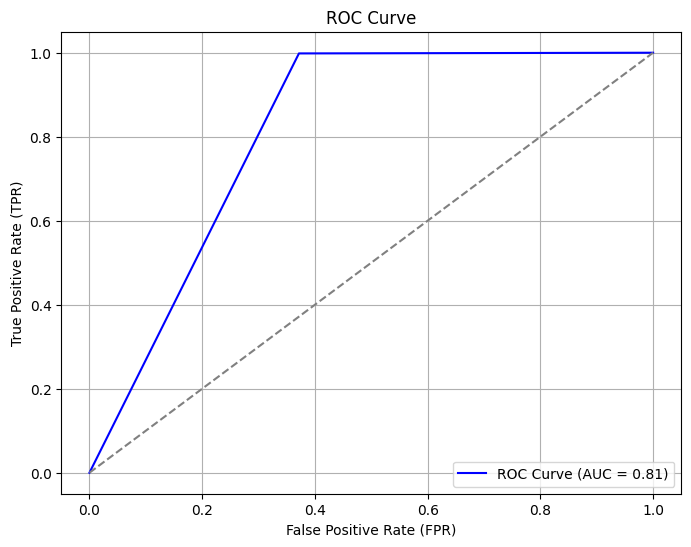

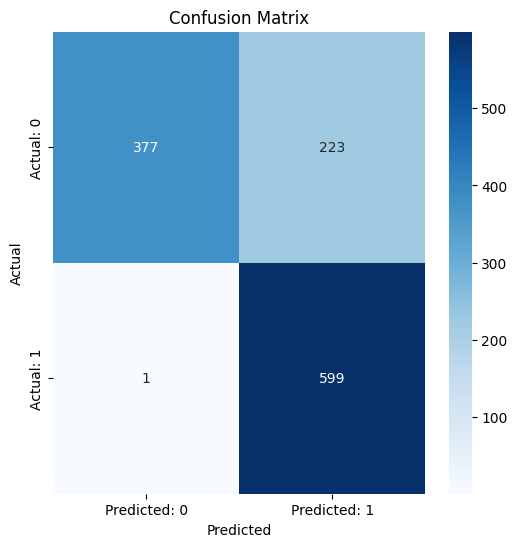

In [82]:
#Predict on the validation set
style_pred_val = multi_task_model.predict([X_test_1, X_test_2])

# Convert predictions to binary values (threshold at 0.5 for binary classification)
style_pred_val = (style_pred_val > 0.5).astype(int)
# # Identify False Positives
# false_positive_indices = [
#     test_indices[i] for i, (true, pred) in enumerate(zip(y_test, style_pred_val)) if true == 0 and pred == 1
# ]

# # Analyze the corresponding attributes
# for idx in false_positive_indices:
#     attributes_img1 = json.loads(df.loc[idx, 'attributes_img1'])
#     attributes_img2 = json.loads(df.loc[idx, 'attributes_img2'])
#     print(f"False Positive Pair {idx}:")
#     print(f"Attributes Image 1: {attributes_img1}")
#     print(f"Attributes Image 2: {attributes_img2}")

# Calculate additional metrics using sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Style output metrics
style_accuracy = accuracy_score(y_test, style_pred_val)
style_precision = precision_score(y_test, style_pred_val)
style_recall = recall_score(y_test, style_pred_val)
style_f1 = f1_score(y_test, style_pred_val)

print(f"Style Output - Accuracy: {style_accuracy:.2f}, Precision: {style_precision:.2f}, Recall: {style_recall:.2f}, F1 Score: {style_f1:.2f}")


from sklearn.metrics import jaccard_score

# Compute Jaccard similarity
jaccard = jaccard_score(y_test, style_pred_val)
print("Jaccard Similarity: ", jaccard)

from sklearn.metrics import cohen_kappa_score

# Calculate Cohen's Kappa
kappa = cohen_kappa_score(y_test, style_pred_val)
print("Cohen's Kappa: ", kappa)

from sklearn.metrics import roc_auc_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, style_pred_val)
print("ROC AUC: ", roc_auc)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, style_pred_val)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line for random classifier
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Compute and plot confusion matrix
cm = confusion_matrix(y_test, style_pred_val)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted: 0", "Predicted: 1"], yticklabels=["Actual: 0", "Actual: 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# # Split the data into training (60%) and a temporary set (40%)
# X_train_1, X_temp_1, y_style_train, y_style_temp = train_test_split(images_1, style_labels, test_size=0.4, random_state=42)
# X_train_2, X_temp_2, y_font_train, y_font_temp = train_test_split(images_2, font_labels, test_size=0.4, random_state=42)

# # Split the temporary set into validation (20%) and test sets (20%)
# X_val_1, X_test_1, y_style_val, y_style_test = train_test_split(X_temp_1, y_style_temp, test_size=0.5, random_state=42)
# X_val_2, X_test_2, y_font_val, y_font_test = train_test_split(X_temp_2, y_font_temp, test_size=0.5, random_state=42)

# # Define callbacks for learning rate scheduling and early stopping
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # Train the model with callbacks
# history = multi_task_model.fit(
#     [X_train_1, X_train_2],  # Inputs for both branches
#     {'style_output': y_style_train, 'font_output': y_font_train},  # Targets for both outputs
#     validation_data=(
#         [X_test_1, X_test_2],
#         {'style_output': y_style_test, 'font_output': y_font_test}
#     ),
#     epochs=100,
#     batch_size=16,
#     callbacks=[reduce_lr, early_stopping]
# )


# # Evaluate on validation set
# val_results = multi_task_model.evaluate(
#     [X_val_1, X_val_2],  # Validation inputs for both images
#     {'style_output': y_style_val, 'font_output': y_font_val}  # Validation labels
# )

# print(f"Validation Loss and Metrics: {val_results}")


## opi6i problema s imenuvaneto

Evaluation

In [ ]:
# Evaluate on validation set
val_results = model.evaluate(
    [X_val_1, X_val_2],  # Validation inputs for both images
    {'style_output': y_style_val, 'font_output': y_font_val}  # Validation labels
)

print(f"Validation Loss and Metrics: {val_results}")


In [ ]:
# Predict on the validation set
style_pred_val, font_pred_val = dual_direction_model.predict([X_val_1, X_val_2])

# Convert predictions to binary values (threshold at 0.5 for binary classification)
style_pred_val = (style_pred_val > 0.5).astype(int)
font_pred_val = (font_pred_val > 0.5).astype(int)

# Calculate additional metrics using sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Style output metrics
style_accuracy = accuracy_score(y_style_val, style_pred_val)
style_precision = precision_score(y_style_val, style_pred_val)
style_recall = recall_score(y_style_val, style_pred_val)
style_f1 = f1_score(y_style_val, style_pred_val)

print(f"Style Output - Accuracy: {style_accuracy:.2f}, Precision: {style_precision:.2f}, Recall: {style_recall:.2f}, F1 Score: {style_f1:.2f}")

# Font output metrics
font_accuracy = accuracy_score(y_font_val, font_pred_val)
font_precision = precision_score(y_font_val, font_pred_val)
font_recall = recall_score(y_font_val, font_pred_val)
font_f1 = f1_score(y_font_val, font_pred_val)

print(f"Font Output - Accuracy: {font_accuracy:.2f}, Precision: {font_precision:.2f}, Recall: {font_recall:.2f}, F1 Score: {font_f1:.2f}")


In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy and loss for both outputs
plt.figure(figsize=(12, 6))

# Plot style output accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['style_output_accuracy'], label='Train Style Accuracy')
plt.plot(history.history['val_style_output_accuracy'], label='Val Style Accuracy')
plt.title('Style Coherence Accuracy')
plt.legend()

# Plot font output accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['font_output_accuracy'], label='Train Font Accuracy')
plt.plot(history.history['val_font_output_accuracy'], label='Val Font Accuracy')
plt.title('Font Similarity Accuracy')
plt.legend()

plt.show()


Style focused only

Proprocessing for mobilenet_v2
Loads the image and resizes it to the specified target size (default: 224x224 for MobileNetV2).
Converts the image into a NumPy array.
Preprocesses the image by scaling pixel values and ensuring it's in the correct format for MobileNetV2 (using the preprocess_input() function).
Expands the dimensions to include the batch size (MobileNetV2 expects input in the shape (batch_size, height, width, channels)).